## Q4 — Fairness & Ethics: Algorithmic Bias across School Tracks

### Context
The GoGymi platform serves students from two distinct academic tracks in the Swiss education system:

**Langzeitgymnasium** is a longer, more academically demanding track entered earlier after primary school, and tends to correlate with higher socioeconomic status. **Kurzzeitgymnasium** is a shorter track, entered later, drawing from a broader demographic.

### Hypothesis
Does the predictive model perform equally well for both tracks? If models perform systematically better for Langzeit students, this could reflect algorithmic bias, amplifying existing socioeconomic inequalities by providing less reliable automated feedback to already disadvantaged students.

### Structure
**Part 1 — Essay performance** (`essay_results.csv`) We reuse the RF model from SQ1 and evaluate whether prediction quality differs between tracks on essay coherence scoring.


**Part 2 — Quiz performance** (`quiz_results.csv`)   ( not done yet).    
We extend the analysis to quiz results, examining whether early behavioral signals predict performance equally well across tracks.

**Part 3 - Early behavior perfromance prediction** 
We then extend RQ3 by investigating whether there is any discrepancy in the behavior prediction between the two tracks

In [ ]:
%load_ext autoreload
%autoreload 2
import numpy as np
import pandas as pd
import math 
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold, cross_validate, cross_val_predict
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.dummy import DummyRegressor
from sklearn.metrics import confusion_matrix


import sys
sys.path.append('..')
sys.path.insert(0, '../Q3')
from utils import *
import importlib
import helpers
importlib.reload(helpers)



<module 'helpers' from 'c:\\Users\\fatum\\Documents\\EPFL\\MA4\\MLBD\\MLBD_2026\\Q4_OverallFairness\\..\\helpers.py'>

In [3]:
data_dir = '../data'
fig_dir = '.'

## **Part 1 — Essay performance** (`essay_results.csv`)  

In [ ]:
essay_results = pd.read_csv(f'{data_dir}/essay_results.csv')


## Step 1 — Track Distribution and Score Analysis

In the GoGymi platform, essay courses map to two school id's that correspond to the two different school tracks :

| course_id | Track | Type |
|---|---|---|
| 5447 | Langzeitgymnasium | Essay |
| 3301 | Kurzzeitgymnasium | Essay |

We first examine whether the two tracks differ in essay volume, score distributions, and writing characteristics, before evaluating whether our model treats them equally.

In [6]:
essay_df = essay_results.copy()
essay_df["track"] = essay_df["course"].map({5447: "Langzeit", 3301: "Kurzzeitgymnasium"})

print(essay_df["track"].value_counts())
print()
print(essay_df.groupby("track")["structure__coherence"].agg(["mean", "std", "count"]))

track
Langzeit             6336
Kurzzeitgymnasium    3859
Name: count, dtype: int64

                       mean       std  count
track                                       
Kurzzeitgymnasium  7.292563  1.484558   3859
Langzeit           7.255447  1.633220   6334


The dataset contains **6,336 Langzeit** and **3,859 Kurzzeitgymnasium** essays, which is roughly a 60/40 split, reflecting the larger enrollment of the longer track.

Mean `structure_coherence` scores are nearly identical across tracks (Langzeit: 7.26, Kurzzeitgymnasium: 7.29), suggesting the AI scorer does not systematically favor either group at the population level. However, Langzeit essays show slightly higher variance (std=1.63 vs 1.48), indicating more spread in writing quality, consistent with a more heterogeneous student population entering the program earlier.

These baseline differences motivate the core fairness question: even if average scores are similar, does the model predict individual scores equally reliably for both groups?

## Step 2 — Feature Engineering (same as SQ1)

In [10]:


essay_df = essay_df.dropna(subset=["course", "text_type", "text", "structure__coherence"]).copy()

essay_df["word_count"] = essay_df["text"].apply(helpers.word_count)
essay_df["char_count"] = essay_df["text"].apply(helpers.char_count)
essay_df["sentence_count"] = essay_df["text"].apply(helpers.sentence_count)
essay_df["avg_sentence_length"] = essay_df["text"].apply(helpers.avg_sentence_length)
essay_df["avg_word_length"] = essay_df["text"].apply(helpers.avg_word_length)
essay_df["lexical_diversity"] = essay_df["text"].apply(helpers.lexical_diversity)
essay_df["comma_count"] = essay_df["text"].apply(helpers.comma_count)
essay_df["semicolon_count"] = essay_df["text"].apply(helpers.semicolon_count)
essay_df["colon_count"] = essay_df["text"].apply(helpers.colon_count)
essay_df["exclamation_count"] = essay_df["text"].apply(helpers.exclamation_count)
essay_df["question_count"] = essay_df["text"].apply(helpers.question_count)
essay_df["long_word_ratio"] = essay_df["text"].apply(helpers.long_word_ratio)

feature_cols = [
    "course", "text_type", "word_count", "char_count", "sentence_count",
    "avg_sentence_length", "avg_word_length", "lexical_diversity",
    "comma_count", "semicolon_count", "colon_count", "exclamation_count",
    "question_count", "long_word_ratio"
]

cat_cols = ["course", "text_type"]
num_cols = [c for c in feature_cols if c not in cat_cols]

X = essay_df[feature_cols].copy()
y = essay_df["structure__coherence"].copy()
track = essay_df["track"].copy()

## Step 3 — Per-group fairness evaluation

Train on full data, evaluate per track using OOF predictions

In [11]:
preprocessor = ColumnTransformer(transformers=[
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]), cat_cols),
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), num_cols)
])

rf_model = Pipeline([
    ("prep", preprocessor),
    ("reg", RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1))
])

cv = KFold(n_splits=5, shuffle=True, random_state=42)
y_pred_oof = cross_val_predict(rf_model, X, y, cv=cv, n_jobs=-1)

# per-group metrics
from sklearn.metrics import mean_absolute_error, r2_score

results = []
for t in ["Langzeit", "Kurzzeitgymnasium"]:
    mask = track == t
    mae = mean_absolute_error(y[mask], y_pred_oof[mask])
    r2 = r2_score(y[mask], y_pred_oof[mask])
    results.append({"Track": t, "N": mask.sum(), "MAE": round(mae, 4), "R²": round(r2, 4)})

df_fairness = pd.DataFrame(results).set_index("Track")
display(df_fairness)

,N,MAE,R²
Track,,,
Langzeit,6239,0.9807,0.3336
Kurzzeitgymnasium,3826,0.9486,0.2712


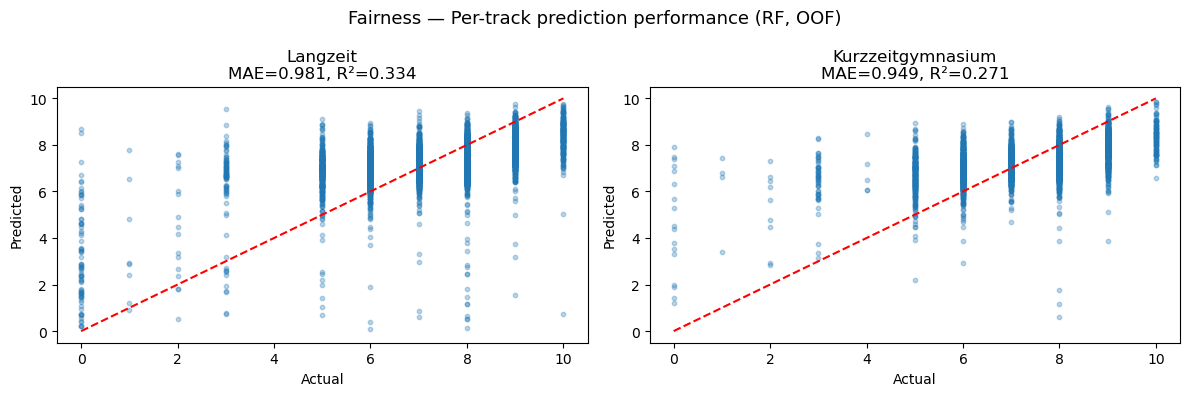

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, track_name in zip(axes, ["Langzeit", "Kurzzeitgymnasium"]):
    mask = track == track_name
    ax.scatter(y[mask], y_pred_oof[mask], alpha=0.3, s=10)
    lims = [y[mask].min(), y[mask].max()]
    ax.plot(lims, lims, "r--")
    ax.set_title(f"{track_name}\nMAE={df_fairness.loc[track_name, 'MAE']:.3f}, R²={df_fairness.loc[track_name, 'R²']:.3f}")
    ax.set_xlabel("Actual")
    ax.set_ylabel("Predicted")

plt.suptitle("Fairness — Per-track prediction performance (RF, OOF)", fontsize=13)
plt.tight_layout()
plt.savefig(f"{fig_dir}/fairness_per_track_scatter.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

Both tracks show the same prediction pattern, no visual difference between them. The R² gap (0.33 vs 0.27) is real but not visible to the naked eye at this scale.

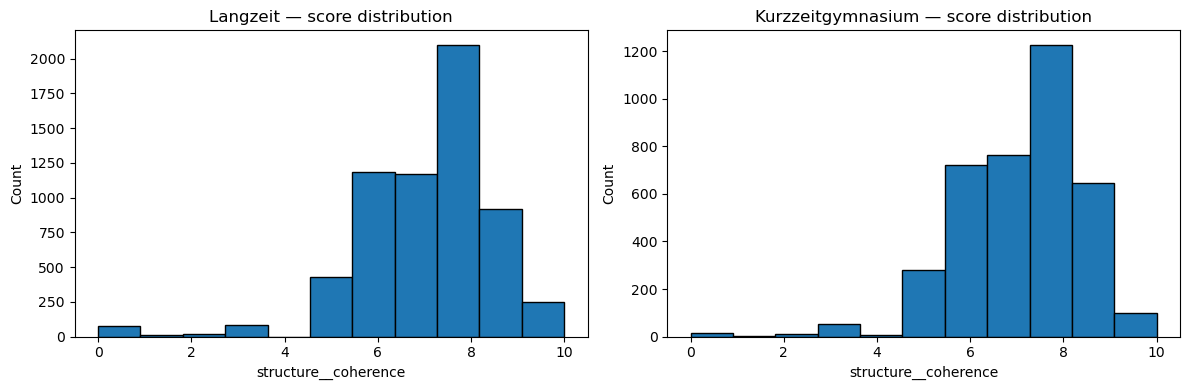

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, track_name in zip(axes, ["Langzeit", "Kurzzeitgymnasium"]):
    mask = track == track_name
    ax.hist(y[mask], bins=11, range=(0,10), edgecolor="black")
    ax.set_title(f"{track_name} — score distribution")
    ax.set_xlabel("structure__coherence")
    ax.set_ylabel("Count")
plt.tight_layout()
plt.savefig(f"{fig_dir}/fairness_score_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

Almost identical between tracks, both peak at 7-8, and we can see the same shape. The AI scorer treats both tracks the same way. Nothing interesting here.

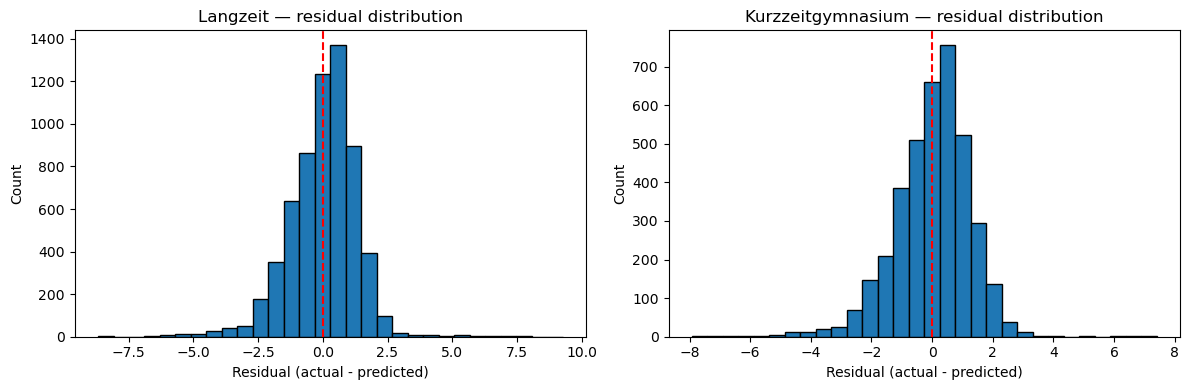

In [14]:
residuals = y.values - y_pred_oof
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, track_name in zip(axes, ["Langzeit", "Kurzzeitgymnasium"]):
    mask = (track == track_name).values
    ax.hist(residuals[mask], bins=30, edgecolor="black")
    ax.axvline(0, color="red", linestyle="--")
    ax.set_title(f"{track_name} — residual distribution")
    ax.set_xlabel("Residual (actual - predicted)")
    ax.set_ylabel("Count")
plt.tight_layout()
plt.savefig(f"{fig_dir}/fairness_residuals.png", dpi=300, bbox_inches="tight")
plt.show()

Both symmetric and centered around 0. We can't see systematic over or under-prediction for either track. 

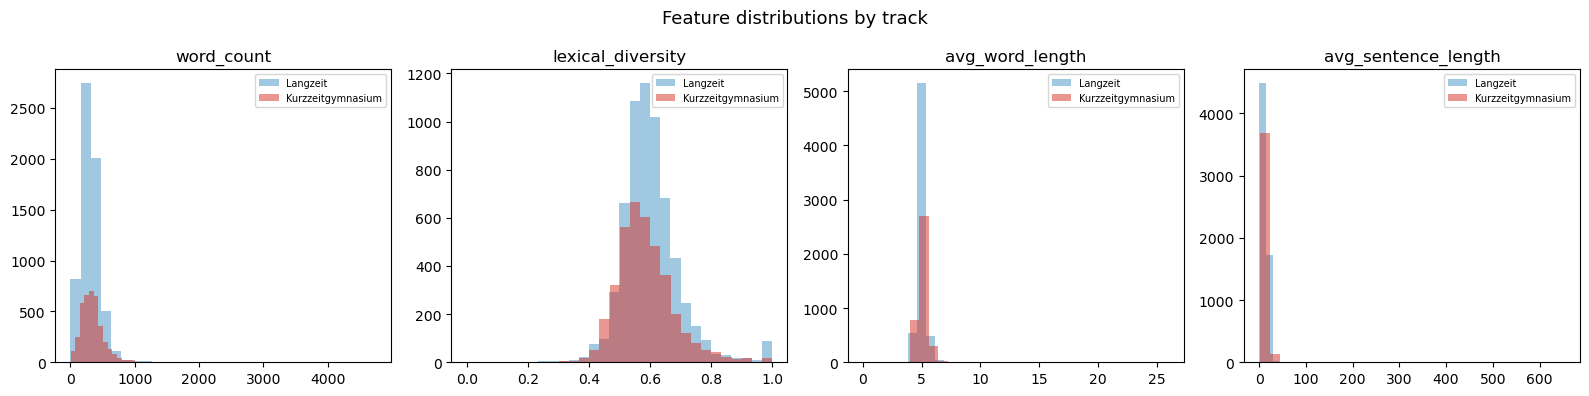

In [15]:
features_to_plot = ["word_count", "lexical_diversity", "avg_word_length", "avg_sentence_length"]
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, feat in zip(axes, features_to_plot):
    for track_name, color in zip(["Langzeit", "Kurzzeitgymnasium"], ["#4393c3", "#d73027"]):
        mask = essay_df["track"] == track_name
        ax.hist(essay_df.loc[mask, feat], bins=30, alpha=0.5, label=track_name, color=color)
    ax.set_title(feat)
    ax.legend(fontsize=7)
plt.suptitle("Feature distributions by track", fontsize=13)
plt.tight_layout()
plt.savefig(f"{fig_dir}/fairness_feature_distributions.png", dpi=300, bbox_inches="tight")
plt.show()

word_count: Langzeit essays are longer on average, which makes sense since it's longer program.

avg_word_length and avg_sentence_length are virtually identical.

## Step 3 — Results and Interpretation

| Track | N | MAE | R² |
|---|---|---|---|
| Langzeit | 6239 | 0.981 | 0.334 |
| Kurzzeitgymnasium | 3826 | 0.949 | 0.271 |

The model performs differently across the two tracks, though not dramatically. MAE is slightly lower for Kurzzeitgymnasium (0.95 vs 0.98), suggesting marginally smaller absolute errors. However R² is notably higher for Langzeit (0.33 vs 0.27), meaning the model explains more variance for that group.

This discrepancy is likely driven by score variance rather than true bias: Langzeit essays show higher standard deviation (1.63 vs 1.48), giving the model more signal to learn from. Kurzzeitgymnasium essays cluster more tightly around the mean, making individual predictions harder to differentiate.

Importantly, the scatter plots reveal that the AI scorer assigns discrete integer scores, producing the vertical banding visible in both plots. This quantization effect limits prediction precision regardless of track, and may itself introduce a form of scoring bias by forcing continuous writing quality into discrete bins.

**Fairness conclusion:** No strong evidence of systematic algorithmic bias against either track. However, the model is less informative for Kurzzeitgymnasium students (lower R²), meaning automated feedback based on this model would be less slightly reliable for that group, which warrants attention given the potential socioeconomic differences between tracks. We tested for bias and found none, at least for the essay part.

## **Part 2 — Quiz performance** (`quiz_results.csv`) 

In [15]:
quiz_results = pd.read_csv(f'{data_dir}/quiz_results.csv')

## **Part 3 - Early behavior perfromance prediction** 

In [3]:
# Load Features from Q3
df_final = pd.read_csv(r"q3_features.csv")
feature_cols = [c for c in df_final.columns if c not in ("user_id", "label")]

## Vizualisation of the feature space using KMeans and prediction with clusters as a feature

Prior work has shown that learners naturally segment into a small number of behaviorally distinct profiles.(Kizilcec, R. F., Piech, https://doi.org/10.1145/2460296.2460330). They established that unsupervised clustering makes subpopulation appear.

We apply K-Means (k=3) to our feature space and project the results onto the first two principal components to assess separability. 

In [10]:

X = df_final[feature_cols].fillna(0) # Handle missing values
y = df_final["label"].astype(int)
X = X.astype('float64')
# 2. Standardize the data
scaler = StandardScaler()
groups = {
    "clicks":    ["clicks__n_total", "clicks__session_gap_cv", "clicks__scroll_depth_max"],
    "exercise":  ["unique_quiz_qids", "unique_math_qids", "unique_text_qids", "q__revisit_rate"],
    "content":   ["content_entropy", "q__n_unique_courses"],
    "media":     ["media__n_play_events", "media__completion_rate", "media__audio_pct"],
}

scaled_parts = []
for name, cols in groups.items():
    available = [c for c in cols if c in df_final.columns]
    scaled_parts.append(pd.DataFrame(
        scaler.fit_transform(df_final[available].fillna(0)),
        columns=available
    ))


X_scaled = pd.concat(scaled_parts, axis=1)


kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled)
df_final['cluster'] = clusters


pca = PCA(n_components=2)
pca_results = pca.fit_transform(X_scaled)
df_final['pca1'] = pca_results[:, 0]
df_final['pca2'] = pca_results[:, 1]


plt.figure(figsize=(10, 7))
sns.scatterplot(
    x='pca1', y='pca2', 
    hue='cluster', 
    palette='viridis', 
    data=df_final, 
    s=100, alpha=0.7
)

plt.title('Student Behavioral Profiles: Clustering by Early Learning Metrics')
plt.xlabel('Principal Component 1 ')
plt.ylabel('Principal Component 2')
plt.legend(title='Student Group')
plt.savefig("PCA.jpg")

![PCA](PCA.jpg)

We observe three profiles: 
- A large group (Yellow) clustered around the origin
- A blue group spread along the positive PC1 axis.
- A small group (Purple) isolated in the positive region.

Let's dig more into what these clusters mean about student behavior.

In [5]:
# Plot clustering profiles 
key_features = [
    "unique_quiz_qids", "unique_math_qids", "q__n_active_days",
    "q__n_questions_viewed", "content_entropy",
    "clicks__session_gap_cv", "clicks__n_total", "media__n_unique_urls", "q__revisit_rate", "media__completion_rate"
]

label_map = {
    "unique_quiz_qids":       "Quiz diversity",
    "unique_math_qids":       "Math diversity",
    "q__n_active_days":       "Active days",
    "q__n_questions_viewed":  "Questions viewed",
    "content_entropy":        "Content entropy",
    "clicks__session_gap_cv": "Session gap CV",
    "clicks__n_total":        "Total clicks",
    "media__n_unique_urls":   "Unique media URLs",
    "q__revisit_rate":        "Revisit rate",
    "media__completion_rate": "Media completion",
}
cluster_labels = {0: "Disengaged", 1: "Engaged", 2: "Moderate"}

key_features = list(label_map.keys())
cluster_means = df_final.groupby("cluster")[key_features].mean()
cluster_means_norm = (cluster_means - cluster_means.mean()) / cluster_means.std()

display = cluster_means_norm.rename(index=cluster_labels, columns=label_map)
fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(display.T, annot=True, fmt=".2f",
    cmap="coolwarm", center=0.5,
    linewidths=0.4, linecolor="white",
    cbar_kws={"shrink": 0.75, "label": "z-score"}, 
    ax=ax
         )
plt.title("Cluster Profiles")
plt.xlabel("Cluster")
plt.savefig("cluster_profile.png")

![Cluster Profile](cluster_profile.png)

This profiling gives interesting insights of the behavior of the students in each clusters.
- Group 0 is bellow average on everything, reflecting disengaged students, that show low activity, low diversity and low regularity in the beginning.
- Group 1 show highly engaged students accross all dimensions.
- Group 2 is a cluster of moderate users.

In [8]:
print("------------------ Outcome Rate ------------------")
print(df_final.groupby("cluster").agg(
    n_students   = ("label", "count"),
    success_rate = ("label", "mean"),
    pct_langzeit = ("q__maj_track", "mean")
).round(3))


------------------ Outcome Rate ------------------
         n_students  success_rate  pct_langzeit
cluster                                        
0                33         0.667         1.000
1               219         0.507         0.420
2               323         0.467         0.353


Surprisingly, the group of disengaged students seem to have the highest success rate, while the moderate ones have the lowest one.
One interesting finding here is that the cluster success rate ordering mirrors the Langzeit representation ordering exactly, suggesting that behavioral engagement on this platform is reflects partially the track of the students. This raises a fundamental question: does our model predict learning success from behavior, or does it predict track membership, which correlates with success through socioeconomic mechanisms outside the platform?

In [11]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
pipe = build_models()["Gradient Boosting"]

kurz_mask = (df_final['q__maj_track'] == 0).values
lang_mask = (df_final['q__maj_track'] == 1).values

kurz_aucs, lang_aucs = [], []

oof_proba = np.zeros(len(X)) 

for train_idx, test_idx in cv.split(X, y):
    pipe.fit(X.iloc[train_idx], y.iloc[train_idx])
    y_prob = pipe.predict_proba(X.iloc[test_idx])[:, 1]
    y_pred = (y_prob >= 0.5).astype(int)
    y_true = y.iloc[test_idx].values

    oof_proba[test_idx] = y_prob
    # Which test indices belong to each track
    kurz_fold = kurz_mask[test_idx]
    lang_fold = lang_mask[test_idx]

    if kurz_fold.any():
        kurz_aucs.append(roc_auc_score(y_true[kurz_fold], y_prob[kurz_fold]))
        
    if lang_fold.any():
        lang_aucs.append(roc_auc_score(y_true[lang_fold], y_prob[lang_fold]))
        

df_final["pred_proba"] = oof_proba
df_final["pred_label"] = (oof_proba >= 0.5).astype(int)

print(f"Kurzeit — AUC: {np.mean(kurz_aucs):.3f}")
print(f"Langzeit — AUC: {np.mean(lang_aucs):.3f}")

Kurzeit — AUC: 0.715
Langzeit — AUC: 0.587


In [12]:
def fairness_metrics(df_kurz, df_lang):
    
    # Confusion Matrix
    cm_kurz = confusion_matrix(df_kurz['label'],df_kurz['pred_label'])
    cm_lang = confusion_matrix(df_lang['label'],df_lang['pred_label'])
    TN_k, FP_k, FN_k, TP_k = cm_kurz.ravel()
    TN_l, FP_l, FN_l, TP_l = cm_lang.ravel()

    
    # Total population
    N_k = TP_k + FP_k + FN_k + TN_k
    N_l = TP_l + FP_l + FN_l + TN_l 

    
    # True positive rate
    tpr_k = TP_k / (TP_k + FN_k) 
    tpr_l = TP_l / (TP_l + FN_l) 


    # Percentage predicted as positive
    ppp_k = (TP_k+FP_k)/N_k
    ppp_l = (TP_l+FP_l)/N_l


    # FNR
    fnr_k = FN_k/(FN_k+TP_k)
    fnr_l = FN_l/(FN_l+TP_l)


    # FPR
    fpr_k = FP_k/(FP_k+TN_k)
    fpr_l = FP_l/(FP_l+TN_l)


    metrics = {
    "TPR : Equal Opportunity":  (tpr_k, tpr_l),
    "FPR : False Positive Rate":   (fpr_k, fpr_l),
    "PPP : Disparate Impact": (ppp_k, ppp_l),
    "FNR : False Negative Rate" : (fnr_k, fnr_l)
    }

    return metrics

In [13]:
metrics = fairness_metrics(df_final[df_final['q__maj_track'] == 0], df_final[df_final['q__maj_track'] == 1])
rows = []
for name, (k, l) in metrics.items():
    rows.append({"Metric": name, "Kurzeit": k, "Langzeit": l, "Gap": abs(k - l)})

results_df = pd.DataFrame(rows).set_index("Metric")
results_df.style\
    .format({"Kurzeit": "{:.3f}", "Langzeit": "{:.3f}", "Gap": "{:.3f}"})\
    .set_caption("Fairness Metrics by Track")

,Kurzeit,Langzeit,Gap
Metric,,,
TPR : Equal Opportunity,0.686,0.495,0.191
FPR : False Positive Rate,0.390,0.371,0.020
PPP : Disparate Impact,0.542,0.427,0.115
FNR : False Negative Rate,0.314,0.505,0.191


In [14]:
print(f"PPP ratio = {0.427/0.542:.2f}")

PPP ratio = 0.79


**Interpretation**
The fairness analysis for sub-question 3 reveals the most pro-
nounced disparities. Using the Gradient Boosting classifier
evaluated via stratified 5-fold cross-validation, the model
achieves AUC = 0.715 for Kurzzeit students but only AUC
= 0.587 for Langzeit students, a gap of 0.128. Per-group
fairness metrics show a false negative rate (FNR) of 0.314 for
Kurzzeit versus 0.505 for Langzeit (gap = 0.191), meaning
the model correctly identifies successful Kurzzeit students
far more reliably than Langzeit ones. The true positive rate
gap mirrors this finding (TPR: 0.686 vs. 0.495). The false
positive rate is comparable across groups (0.390 vs. 0.371,
gap = 0.020), indicating that the asymmetry is specific to
the prediction of success rather than struggle. The disparate
impact ratio (PPP ratio = 0.79) falls below the commonly
used 80% threshold, suggesting a meaningful disparity in
positive predictions across tracks.